<a href="https://colab.research.google.com/github/masha713/ML_demeshok/blob/main/%D0%9B%D0%912_%D0%94%D0%B5%D0%BC%D0%B5%D1%88%D0%BE%D0%BA_3_10_%D0%97%D0%B0%D0%B2%D0%B4%D0%B0%D0%BD%D0%BD%D1%8F_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота 2. Прізвище, група

---



# Завдання 1

**Була присутня на парі**

Обробка та нааліз даних про ВВП країн. Датасет було отримано з Вікіпедії з використанням бібілотеки Pandas.

1. Вивести перші 5 рядків датасета

In [3]:
import numpy as np
import pandas as pd
import requests

In [9]:
url = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(nominal)"
html = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}).text
tables = pd.read_html(html)
df = tables[2]
df.head()

/tmp/ipykernel_943/1115015283.py:3: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(html)


,Country/Territory,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211


In [10]:
df.columns

Index(['Country/Territory', 'IMF (2026)[1]', 'World Bank (2025)[6]',
       'United Nations (2024)[7]'],
      dtype='object')

2.	Визначити розмір датасета.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222 entries, 0 to 221
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Country/Territory         222 non-null    object
 1   IMF (2026)[1]             222 non-null    object
 2   World Bank (2025)[6]      222 non-null    object
 3   United Nations (2024)[7]  222 non-null    object
dtypes: object(4)
memory usage: 7.1+ KB


 3.	Визначити оптимальну кількість стовпців (видалити зайві, на власний розсуд).

In [12]:
df.columns = (df.columns
              .str.replace(r'(?:\s*\[Id+\])+', '', regex=True)
              .str.replace('Country/Territory', 'Country', regex=False))
df

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
0,World,126295331,118350166,111565144
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


In [15]:
df = df.drop(df[df.iloc[:, 0] == "World"].index)
df

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
1,United States,32383920,30769700,29298000
2,China[n 1],20851593,19498039,18743802
3,Germany,5452858,5050923,4659929
4,Japan,4379253,4435163,4026211
5,United Kingdom,4264794,4002588,3685881
...,...,...,...,...
217,Palau,377,345,310
218,Marshall Islands,342,308,281
219,Nauru,196,176,187
220,Montserrat,—N/a,—N/a,81


4.	Замініть у таблиці значення "—" на значення NaN. Перевірити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [16]:
df.isnull().sum()

,0
Country,0
IMF (2026)[1],0
World Bank (2025)[6],0
United Nations (2024)[7],0


In [17]:
df['IMF (2026)[1]'] = pd.to_numeric(df['IMF (2026)[1]'], errors='coerce')
df['World Bank (2025)[6]'] = pd.to_numeric(df['World Bank (2025)[6]'], errors='coerce')
df['United Nations (2024)[7]'] = pd.to_numeric(df['United Nations (2024)[7]'], errors='coerce')

In [18]:
df.dtypes

,0
Country,object
IMF (2026)[1],float64
World Bank (2025)[6],float64
United Nations (2024)[7],float64


In [19]:
df

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
1,United States,32383920.0,30769700.0,29298000.0
2,China[n 1],20851593.0,19498039.0,18743802.0
3,Germany,5452858.0,5050923.0,4659929.0
4,Japan,4379253.0,4435163.0,4026211.0
5,United Kingdom,4264794.0,4002588.0,3685881.0
...,...,...,...,...
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,NaN,NaN,81.0


In [20]:
df.isnull().sum()

,0
Country,0
IMF (2026)[1],31
World Bank (2025)[6],35
United Nations (2024)[7],9


In [21]:
df.iloc[:, 1:] = df.iloc[:, 1:].apply(lambda x: x.fillna(x.mean()), axis=1)

df.isnull().sum()

,0
Country,0
IMF (2026)[1],8
World Bank (2025)[6],8
United Nations (2024)[7],8


In [22]:
part = df.iloc[:,1:]

row_filled = part.apply(lambda r: r.fillna(r.mean()), axis=1)
col_means = part.mean()

df.iloc[:, 1:] = row_filled.fillna(col_means)

df.isnull().sum()

,0
Country,0
IMF (2026)[1],0
World Bank (2025)[6],0
United Nations (2024)[7],0


5. Ще раз вивести датасет

In [23]:
df.tail()

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
217,Palau,377.0,345.0,310.0
218,Marshall Islands,342.0,308.0,281.0
219,Nauru,196.0,176.0,187.0
220,Montserrat,81.0,81.0,81.0
221,Tuvalu,65.0,57.0,56.0


6.	Перевірити наявність дублікатів. При наявності видалити дублікати.

In [24]:
df.duplicated().sum()

np.int64(0)

7.	Вивести описову статистику датасету describe()

In [25]:
df.describe()

,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7]
count,2.210000e+02,2.210000e+02,2.210000e+02
mean,5.943385e+05,5.561409e+05,5.246237e+05
std,2.673673e+06,2.527950e+06,2.410273e+06
min,6.500000e+01,5.700000e+01,5.600000e+01
25%,9.442000e+03,9.233000e+03,8.840000e+03
50%,4.884900e+04,4.809900e+04,4.276500e+04
75%,3.773650e+05,3.348550e+05,2.986970e+05
max,3.238392e+07,3.076970e+07,2.929800e+07


8. Визначте відхилення (різницю) між показниками IMF (2026) та World Bank (2025) для кожної країни. У яких країнах ці показники найбільше відрізняються (дати відповідь)?

In [26]:
df['IMF_WB_Diff'] = abs(df['IMF (2026)[1]'] - df['World Bank (2025)[6]'])

max_diff = df['IMF_WB_Diff'].max()

country = df[df['IMF_WB_Diff'] == max_diff]['Country'].values[0]
print(f'(country) has the largest difference between IMF and WB: (max_diff)')

df.head(10)

(country) has the largest difference between IMF and WB: (max_diff)


,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0
3,Germany,5452858.0,5050923.0,4659929.0,401935.0
4,Japan,4379253.0,4435163.0,4026211.0,55910.0
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0
6,India,4153191.0,3956067.0,3952244.0,197124.0
7,France,3596094.0,3366316.0,3160443.0,229778.0
8,Italy,2738164.0,2551557.0,2380825.0,186607.0
9,Russia,2656452.0,2561310.0,2173386.0,95142.0
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0


9.	Обчисліть кореляцію між показниками IMF (2026), World Bank (2025) та United Nations (2024). Які пари змінних мають найвищу кореляцію?

In [27]:
cor_IMF_WB = df['IMF (2026)[1]'].corr(df['World Bank (2025)[6]'])
cor_IMF_UN = df['IMF (2026)[1]'].corr(df['United Nations (2024)[7]'])
cor_WB_UN = df['World Bank (2025)[6]'].corr(df['United Nations (2024)[7]'])

print(f'Correlation between IMF and WB: {cor_IMF_WB}')
print(f'Correlation between IMF and UN: {cor_IMF_UN}')
print(f'Correlation between WB and UN: {cor_WB_UN}')

Correlation between IMF and WB: 0.9998772853399375
Correlation between IMF and UN: 0.9998162531253877
Correlation between WB and UN: 0.9998603541665632


In [28]:
max_cor = max(cor_IMF_WB, cor_IMF_UN, cor_WB_UN)
if max_cor == cor_IMF_WB:
  print('IMF and WB have the highest correlation')
elif max_cor == cor_IMF_UN:
  print('IMF and UN have the highest correlation')
else:
  print('WB and UN have the highest correlation')

IMF and WB have the highest correlation


Обчислити середнє значення за стовпцями

In [29]:
mean_IMF = df['IMF (2026)[1]'].mean()
mean_IMF

np.float64(594338.5211267605)

In [30]:
mean_WB = df['World Bank (2025)[6]']
mean_WB

,World Bank (2025)[6]
1,30769700.0
2,19498039.0
3,5050923.0
4,4435163.0
5,4002588.0
...,...
217,345.0
218,308.0
219,176.0
220,81.0


In [31]:
mean_UN = df['United Nations (2024)[7]']
mean_UN

,United Nations (2024)[7]
1,29298000.0
2,18743802.0
3,4659929.0
4,4026211.0
5,3685881.0
...,...
217,310.0
218,281.0
219,187.0
220,81.0


11.	Обчисліть стандартне відхилення показників для кожної країни. Яка країна має найвищу варіативність у показниках між роками?

In [32]:
df['std'] = df.iloc[:, 1:].std(axis=1)

max_std = df['std'].max()
country = df[df['std'] == max_std]['Country'].values[0]
print(f'{country} has the highest standard deviation: {max_std}')

df.head(10)

United States has the highest standard deviation: 14655779.964896671


,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff,std
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06


12.	Визначення країни з найвищим та найнижчим показниками: Знайдіть країну з найвищим та найнижчим показниками у кожному з років (IMF (2026), World Bank (2025), United Nations (2024)).

In [33]:
max_IMF = df['IMF (2026)[1]'].max(); min_IMF = df['IMF (2026)[1]'].min()
max_WB = df['World Bank (2025)[6]'].max(); min_WB = df['World Bank (2025)[6]'].min()
max_UN = df['United Nations (2024)[7]'].max(); min_UN = df['United Nations (2024)[7]'].min()

print(f'Max IMF: {max_IMF}, Min IMF: {min_IMF}')
print(f'Max WB: {max_WB}, Min WB: {min_WB}')
print(f'Max UN: {max_UN}, Min UN: {min_UN}')

Max IMF: 32383920.0, Min IMF: 65.0
Max WB: 30769700.0, Min WB: 57.0
Max UN: 29298000.0, Min UN: 56.0


13.	Побудуйте гістограму для розподілу показників IMF (2026) серед всіх країн. Який вигляд має розподіл? Чи є країни, що виділяються?

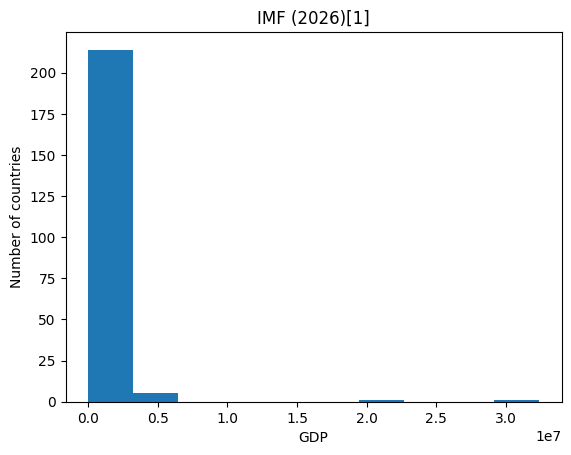

In [34]:
import matplotlib.pyplot as plt

# Build a histogram of IMF_Forecast
plt.hist(df['IMF (2026)[1]'], bins=10)
plt.title('IMF (2026)[1]')
plt.xlabel('GDP')
plt.ylabel('Number of countries')
plt.show()

14.	Розрахуйте частку кожної країни в загальному значенні для кожного року (IMF (2026), World Bank (2025), United Nations (2024)).
 Як змінюються частки країн з часом (дати відповідь)?

In [35]:
df['IMF_Share'] = df['IMF (2026)[1]'] / df['IMF (2026)[1]'].sum()
df['WB_Share'] = df['World Bank (2025)[6]'] / df['World Bank (2025)[6]'].sum()
df['UN_Share'] = df['United Nations (2024)[7]'] / df['United Nations (2024)[7]'].sum()

df.head(10)

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.246549,0.250349,0.252696
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.158750,0.158640,0.161666
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.041514,0.041095,0.040192
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.033341,0.036085,0.034726
5,United Kingdom,4264794.0,4002588.0,3685881.0,262206.0,1.876098e+06,0.032469,0.032566,0.031791
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.031620,0.032187,0.034088
7,France,3596094.0,3366316.0,3160443.0,229778.0,1.582291e+06,0.027378,0.027389,0.027259
8,Italy,2738164.0,2551557.0,2380825.0,186607.0,1.194072e+06,0.020847,0.020760,0.020535
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.020224,0.020839,0.018745
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.020068,0.018550,0.018853


15.	Візуалізуйте зміни в показниках для кожної країни за три роки на графіку. Які країни показують стабільне зростання або спад (дати відповідь)?

In [36]:
df['IMF_UN_Diff'] = abs(df['IMF_Share'] - df['UN_Share'])
df_top10= df.nlargest(10, 'IMF_UN_Diff')
df_top10

,Country,IMF (2026)[1],World Bank (2025)[6],United Nations (2024)[7],IMF_WB_Diff,std,IMF_Share,WB_Share,UN_Share,IMF_UN_Diff
1,United States,32383920.0,30769700.0,29298000.0,1614220.0,1.465578e+07,0.246549,0.250349,0.252696,0.006147
2,China[n 1],20851593.0,19498039.0,18743802.0,1353554.0,9.213488e+06,0.158750,0.158640,0.161666,0.002916
6,India,4153191.0,3956067.0,3952244.0,197124.0,1.913990e+06,0.031620,0.032187,0.034088,0.002469
53,Iran,300293.0,362682.0,448092.0,62389.0,1.654723e+05,0.002286,0.002951,0.003865,0.001579
9,Russia,2656452.0,2561310.0,2173386.0,95142.0,1.202576e+06,0.020224,0.020839,0.018745,0.001479
15,South Korea,1931008.0,1872375.0,1875388.0,58633.0,9.175414e+05,0.014701,0.015234,0.016175,0.001474
4,Japan,4379253.0,4435163.0,4026211.0,55910.0,2.119895e+06,0.033341,0.036085,0.034726,0.001385
3,Germany,5452858.0,5050923.0,4659929.0,401935.0,2.348734e+06,0.041514,0.041095,0.040192,0.001322
10,Brazil,2635912.0,2279920.0,2185822.0,355992.0,1.024125e+06,0.020068,0.018550,0.018853,0.001215
16,Turkey,1640223.0,1597293.0,1323255.0,42930.0,7.518882e+05,0.012488,0.012996,0.011413,0.001074
